## Introduction
This example will show the steps needed to build a 3D convolutional neural network (CNN) to predict the presence of viral pneumonia in computer tomography (CT) scans. 2D CNNs are commonly used to process RGB images (3 channels). A 3D CNN is simply the 3D equivalent: it takes as input a 3D volume or a sequence of 2D frames (e.g. slices in a CT scan), 3D CNNs are a powerful model for learning representations for volumetric data.

This notebook improves upon the original work [1], achieving ~92% accuracy by:
- Augmenting the original dataset with rotation, contrast adjustment, random noise, scaling, and cropping the images.
- Intelligently searching for optimal hyperparameters for the neural network.
- Increasing the convolutional filter size and adding dropout to the network.
- Training the best hyperparameters for 250 epoch.

## References
1) [3D image classification from CT scans](https://keras.io/examples/vision/3D_image_classification/)<br>
2) [A survey on Deep Learning Advances on Different 3D DataRepresentations](https://arxiv.org/abs/1808.01462)<br>
3) [VoxNet: A 3D Convolutional Neural Network for Real-Time Object Recognition](https://www.ri.cmu.edu/pub_files/2015/9/voxnet_maturana_scherer_iros15.pdf)<br>
4) [FusionNet: 3D Object Classification Using MultipleData Representations](https://arxiv.org/abs/1607.05695)<br>
5) [Uniformizing Techniques to Process CT scans with 3D CNNs for Tuberculosis Prediction](https://arxiv.org/abs/2007.13224)<br>



<br>
## Setup<br>


In [30]:
import os
import zipfile
import numpy as np
import random
import nibabel as nib
from scipy import ndimage
import matplotlib.pyplot as plt
import tensorflow as tf  # for data preprocessing
import keras
from keras import layers
import keras_tuner as kt
from tensorflow.keras.models import Sequential  # Create sequential layered neural networks
from tensorflow.keras.optimizers import ( # Optimizers
    Adam,
    Adadelta,
    Lamb,
    RMSprop,
    SGD
)
from tensorflow.keras.layers import (
   Input,
   Conv2D,  # 2D convolutional layers for images
   Conv3D,  # 3D convolutional layers for images
   LeakyReLU,  # Activation function layers
   Softmax,   # Activation function layers
   MaxPool2D,  # Maximum pooling layers
   MaxPool3D,  # Maximum pooling layers
   GlobalAveragePooling3D,
   Flatten,  # Flatten layers into 1D vectors
   Dense,  # Fully connected layer
   Dropout,  # Delete/ignore certain neurons to avoid overfitting
   BatchNormalization  # Normalize layer inputs for improved performance
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical  # One-hot encoder for categorical features
from tensorflow.keras.losses import CategoricalCrossentropy, SparseCategoricalCrossentropy  # Loss function
from tensorflow.keras.metrics import Accuracy  # Accuracy metric to evaluate model performance
import warnings
warnings.filterwarnings('ignore')

## Downloading the MosMedData: Chest CT Scans with COVID-19 Related Findings
In this example, we use a subset of the 
[MosMedData: Chest CT Scans with COVID-19 Related Findings](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1).
This dataset consists of lung CT scans with COVID-19 related findings, as well as without such findings. We will be using the associated radiological findings of the CT scans as labels to build a classifier to predict presence of viral pneumonia. Hence, the task is a binary classification problem.


In [85]:
# Download URL of normal CT scans.
url = "https://github.com/hasibzunair/3D-image-classification-tutorial/releases/download/v0.2/CT-0.zip"
# Use cache_dir to specify the directory and fname for the file name
keras.utils.get_file(
    fname="CT-0.zip",
    origin=url,
    cache_dir=os.path.abspath("/content"),
    cache_subdir="."
)

'/tmp/.keras/./CT-0.zip'

In [86]:
# Download URL of normal CT scans.
url = "https://github.com/hasibzunair/3D-image-classification-tutorial/releases/download/v0.2/CT-23.zip"
keras.utils.get_file(
    fname="CT-23.zip",
    origin=url,
    cache_dir=os.path.abspath("/content"),
    cache_subdir="."
)

'/tmp/.keras/./CT-23.zip'

In [33]:
data_dir = "/Users/socrates/Documents/workspace/Tensorflow/data/"
#os.makedirs(data_dir+"MosMedData/")

In [34]:
with zipfile.ZipFile(data_dir+"CT-0.zip", "r") as z_fp:
    z_fp.extractall(data_dir)

In [35]:
with zipfile.ZipFile(data_dir+"CT-23.zip", "r") as z_fp:
    z_fp.extractall("./MosMedData/")

## Loading data and preprocessing
The files are provided in Nifti format with the extension .nii. To read the scans, we use the `nibabel` package. You can install the package via `pip install nibabel`. CT scans store raw voxel intensity in Hounsfield units (HU). They range from -1024 to above 2000 in this dataset. Above 400 are bones with different radiointensity, so this is used as a higher bound. A threshold between -1000 and 400 is commonly used to normalize CT scans.

To process the data, we do the following:
* We first rotate the volumes by 90 degrees, so the orientation is fixed
* We scale the HU values to be between 0 and 1.
* We resize width, height and depth.

Here we define several helper functions to process the data. These functions will be used when building training and validation datasets.


In [36]:
def read_nifti_file(filepath):
    """Read and load volume"""
    # Read file
    scan = nib.load(filepath)
    # Get raw data
    scan = scan.get_fdata()
    return scan

In [37]:
def normalize(volume):
    """Normalize the volume"""
    min = -1000
    max = 400
    volume[volume < min] = min
    volume[volume > max] = max
    volume = (volume - min) / (max - min)
    volume = volume.astype("float32")
    return volume

In [38]:
def resize_volume(img):
    """Resize across z-axis"""
    # Set the desired depth
    desired_depth = 64
    desired_width = 128
    desired_height = 128
    # Get current depth
    current_depth = img.shape[-1]
    current_width = img.shape[0]
    current_height = img.shape[1]
    # Compute depth factor
    depth = current_depth / desired_depth
    width = current_width / desired_width
    height = current_height / desired_height
    depth_factor = 1 / depth
    width_factor = 1 / width
    height_factor = 1 / height
    # Rotate
    img = ndimage.rotate(img, 90, reshape=False)
    # Resize across z-axis
    img = ndimage.zoom(img, (width_factor, height_factor, depth_factor), order=1)
    return img

In [39]:
def process_scan(path):
    """Read and resize volume"""
    # Read scan
    volume = read_nifti_file(path)
    # Normalize
    volume = normalize(volume)
    # Resize width, height and depth
    volume = resize_volume(volume)
    return volume

<br>
Let's read the paths of the CT scans from the class directories.<br>
Folder "CT-0" consist of CT scans having normal lung tissue, no CT-signs of viral pneumonia.

In [40]:
normal_scan_paths = [
    os.path.join(os.getcwd(), "MosMedData/CT-0", x)
    for x in os.listdir("MosMedData/CT-0")
]
# Folder "CT-23" consist of CT scans having several ground-glass opacifications,
# involvement of lung parenchyma.
abnormal_scan_paths = [
    os.path.join(os.getcwd(), "MosMedData/CT-23", x)
    for x in os.listdir("MosMedData/CT-23")
]

In [41]:
print("CT scans with normal lung tissue: " + str(len(normal_scan_paths)))
print("CT scans with abnormal lung tissue: " + str(len(abnormal_scan_paths)))

CT scans with normal lung tissue: 100
CT scans with abnormal lung tissue: 100


## Build train and validation datasets
Read the scans from the class directories and assign labels. Downsample the scans to have shape of 128x128x64. Rescale the raw HU values to the range 0 to 1. Lastly, split the dataset into train and validation subsets.

Read and process the scans. Each scan is resized across height, width, and depth and rescaled.

In [42]:
abnormal_scans = np.array([process_scan(path) for path in abnormal_scan_paths])
normal_scans = np.array([process_scan(path) for path in normal_scan_paths])

For the CT scans having presence of viral pneumonia assign 1, for the normal ones assign 0.

In [43]:
abnormal_labels = np.array([1 for _ in range(len(abnormal_scans))])
normal_labels = np.array([0 for _ in range(len(normal_scans))])

Split data in the ratio 70-30 for training and validation.

In [44]:
x_train = np.concatenate((abnormal_scans[:70], normal_scans[:70]), axis=0)
y_train = np.concatenate((abnormal_labels[:70], normal_labels[:70]), axis=0)
x_val = np.concatenate((abnormal_scans[70:], normal_scans[70:]), axis=0)
y_val = np.concatenate((abnormal_labels[70:], normal_labels[70:]), axis=0)
print(
    "Number of samples in train and validation are %d and %d."
    % (x_train.shape[0], x_val.shape[0])
)

Number of samples in train and validation are 140 and 60.


## Data augmentation
The CT scans also augmented by rotating at random angles during training. Since the data is stored in rank-3 tensors of shape `(samples, height, width, depth)`, we add a dimension of size 1 at axis 4 to be able to perform 3D convolutions on the data. The new shape is thus `(samples, height, width, depth, 1)`. There are different kinds of preprocessing and augmentation techniques out there, this example shows a few simple ones to get started.

In [45]:
import random

In [46]:
def augment_volume(volume):
    """Randomly apply various augmentations to the 3D volume."""
    def scipy_augment(volume):
        # 1. Rotation
        angles = [-20, -10, -5, 5, 10, 20]
        if random.random() > 0.5:
            angle = random.choice(angles)
            volume = ndimage.rotate(volume, angle, reshape=False)

        # 2. Contrast adjustments
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            mean = np.mean(volume)
            volume = (volume - mean) * factor + mean

        # 3. Gaussian noise
        if random.random() > 0.5:
            noise = np.random.normal(0, 0.05, volume.shape)
            volume = volume + noise

        # 4. Random scaling (zoom) and center crop
        if random.random() > 0.5:
            zoom_factor = random.uniform(1.0, 1.2)
            zoomed = ndimage.zoom(volume, (zoom_factor, zoom_factor, zoom_factor), order=1)

            # Center crop back to original dimensions
            x, y, z = volume.shape
            zx, zy, zz = zoomed.shape
            sx = (zx - x) // 2
            sy = (zy - y) // 2
            sz = (zz - z) // 2
            volume = zoomed[sx:sx+x, sy:sy+y, sz:sz+z]

            # Pad if rounding caused size mismatch
            px = max(0, x - volume.shape[0])
            py = max(0, y - volume.shape[1])
            pz = max(0, z - volume.shape[2])
            volume = np.pad(volume, ((0, px), (0, py), (0, pz)), mode='constant')[:x, :y, :z]

        # 5. Elastic deformation (kept at lower probability due to compute cost)
        if random.random() > 0.75:
            alpha, sigma = 10, 3
            shape = volume.shape
            dx = ndimage.gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
            dy = ndimage.gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
            dz = ndimage.gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha

            x_grid, y_grid, z_grid = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), np.arange(shape[2]), indexing='ij')
            indices = np.reshape(x_grid+dx, (-1, 1)), np.reshape(y_grid+dy, (-1, 1)), np.reshape(z_grid+dz, (-1, 1))
            volume = ndimage.map_coordinates(volume, indices, order=1, mode='reflect').reshape(shape)

        # Ensure volume values remain between 0 and 1
        volume = np.clip(volume, 0, 1)
        return volume

    # The volume shape is (128, 128, 64) after `resize_volume`
    # Use tf.py_function and then set the shape explicitly
    augmented_volume = tf.py_function(scipy_augment, [volume], tf.float32)
    augmented_volume.set_shape([128, 128, 64])
    return augmented_volume

In [47]:
def train_preprocessing(volume, label):
    """Process training data by applying augmentations and adding a channel."""
    # Augment volume
    volume = augment_volume(volume)
    volume = tf.expand_dims(volume, axis=3)
    return volume, label

In [48]:
def validation_preprocessing(volume, label):
    """Process validation data by only adding a channel."""
    volume = tf.expand_dims(volume, axis=3)
    return volume, label

While defining the train and validation data loader, the training data is passed through and augmentation function which randomly rotates volume at different angles. Note that both training and validation data are already rescaled to have values between 0 and 1.

Define data loaders.

In [49]:
train_loader = tf.data.Dataset.from_tensor_slices((x_train, y_train))
validation_loader = tf.data.Dataset.from_tensor_slices((x_val, y_val))

In [50]:
batch_size = 2
# Augment the on the fly during training.
train_dataset = (
    train_loader.shuffle(len(x_train))
    .map(train_preprocessing)
    .batch(batch_size)
    .prefetch(2)
)
# Only rescale.
validation_dataset = (
    validation_loader.shuffle(len(x_val))
    .map(validation_preprocessing)
    .batch(batch_size)
    .prefetch(2)
)


<br>
Visualize an augmented CT scan.<br>


In [51]:
import matplotlib.pyplot as plt

Dimension of the CT scan is: (128, 128, 64, 1)


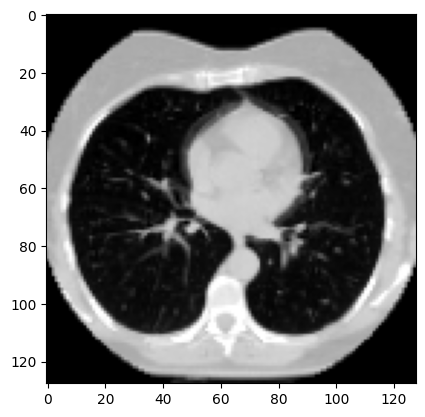

In [52]:
data = train_dataset.take(1)
images, labels = list(data)[0]
images = images.numpy()
image = images[0]
print("Dimension of the CT scan is:", image.shape)
plt.imshow(np.squeeze(image[:, :, 30]), cmap="gray")


<br>
Since a CT scan has many slices, let's visualize a montage of the slices.<br>


In [53]:
def plot_slices(num_rows, num_columns, width, height, data):
    """Plot a montage of 20 CT slices"""
    data = np.rot90(np.array(data))
    data = np.transpose(data)
    data = np.reshape(data, (num_rows, num_columns, width, height))
    rows_data, columns_data = data.shape[0], data.shape[1]
    heights = [slc[0].shape[0] for slc in data]
    widths = [slc.shape[1] for slc in data[0]]
    fig_width = 12.0
    fig_height = fig_width * sum(heights) / sum(widths)
    f, axarr = plt.subplots(
        rows_data,
        columns_data,
        figsize=(fig_width, fig_height),
        gridspec_kw={"height_ratios": heights},
    )
    for i in range(rows_data):
        for j in range(columns_data):
            axarr[i, j].imshow(data[i][j], cmap="gray")
            axarr[i, j].axis("off")
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()

Visualize montage of slices.<br>
4 rows and 10 columns for 100 slices of the CT scan.

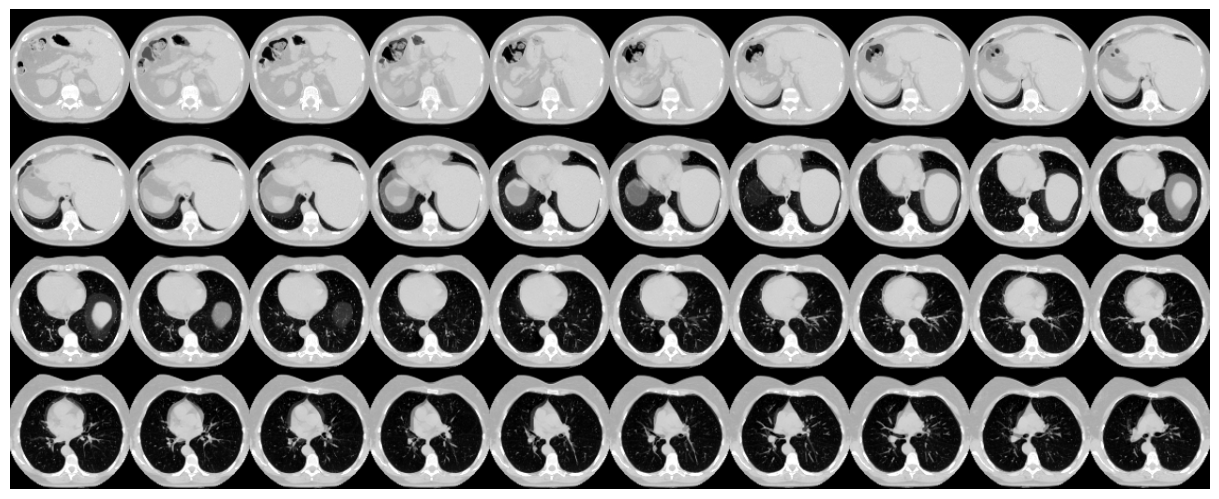

In [54]:
plot_slices(4, 10, 128, 128, image[:, :, :40])

## Define a 3D convolutional neural network
To make the model easier to understand, we structure it into blocks. The architecture of the 3D CNN used in this example is based on [this paper](https://arxiv.org/abs/2007.13224).

In [63]:
def build_cnn_model(hp, width=128, height=128, depth=64):
    conv_args = {
        "kernel_initializer": "orthogonal",
        "padding": "same",
    }
    model = Sequential()
    # Correctly define input shape in the first Conv3D layer
    model.add(Conv3D(filters=64, kernel_size=3, input_shape=(width, height, depth, 1), **conv_args))
    # Replaced misplaced Dense layer with Activation layer
    model.add(layers.Activation(hp.Choice("activation1", ["relu", "silu", "celu", "gelu"])))
    model.add(MaxPool3D(pool_size=2))
    model.add(BatchNormalization())

    model.add(Conv3D(filters=64, kernel_size=3, **conv_args))
    # Replaced misplaced Dense layer with Activation layer
    model.add(layers.Activation(hp.Choice("activation2", ["relu", "silu", "celu", "gelu"])))
    model.add(MaxPool3D(pool_size=2))
    model.add(BatchNormalization())

    model.add(Conv3D(filters=128, kernel_size=3, **conv_args))
    # Replaced misplaced Dense layer with Activation layer
    model.add(layers.Activation(hp.Choice("activation3", ["relu", "silu", "celu", "gelu"])))
    model.add(MaxPool3D(pool_size=2))
    model.add(BatchNormalization())

    model.add(Conv3D(filters=256, kernel_size=3, **conv_args))
    # Replaced misplaced Dense layer with Activation layer
    model.add(layers.Activation(hp.Choice("activation4", ["relu", "silu", "celu", "gelu"])))
    model.add(MaxPool3D(pool_size=2))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling3D())
    model.add(Dense(units=512)) # Dense layer for feature reduction
    model.add(layers.Activation(hp.Choice("activation5", ["relu", "silu", "celu", "gelu"])))
    model.add(Dropout(hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(units=1, activation=hp.Choice("activation6", ["sigmoid", "squareplus"])))

    # Tune the learning rate
    initial_learning_rate = 0.0001
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(initial_learning_rate, decay_steps=100000, decay_rate=0.96, staircase=True)
    opt=tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile the model
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=['accuracy'])
    return model

In [64]:
import tensorboard # Import tensorboard explicitly to ensure it's available

model = build_cnn_model(kt.HyperParameters())
model.summary()

# Search for the best hyperparameters optimizing for validation accuracy
tuner = kt.RandomSearch(
    hypermodel=build_cnn_model,
    objective="accuracy",
    max_trials=25,
    executions_per_trial=1,
    overwrite=True,
    directory="3d-img-classification",
    project_name="3d-img-classification",
)
tuner.search_space_summary()

checkpoint = keras.callbacks.ModelCheckpoint("3d_image_classification.keras", save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(monitor="accuracy", mode='max', patience=5, restore_best_weights=True)
tuner.search(x=train_dataset, validation_data=validation_dataset, epochs=30, callbacks=[checkpoint, early_stopping])
tuner.results_summary()

# Get the top 2 models
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

Trial 25 Complete [01h 05m 24s]
accuracy: 0.6785714030265808

Best accuracy So Far: 0.7071428298950195
Total elapsed time: 1d 00h 52m 11s
Results summary
Results in 3d-img-classification/3d-img-classification
Showing 10 best trials
Objective(name="accuracy", direction="max")

Trial 02 summary
Hyperparameters:
activation1: gelu
activation2: relu
activation3: silu
activation4: celu
activation5: celu
dropout: 0.5
activation6: sigmoid
Score: 0.7071428298950195

Trial 14 summary
Hyperparameters:
activation1: relu
activation2: gelu
activation3: gelu
activation4: silu
activation5: silu
dropout: 0.1
activation6: sigmoid
Score: 0.699999988079071

Trial 22 summary
Hyperparameters:
activation1: silu
activation2: relu
activation3: relu
activation4: relu
activation5: silu
dropout: 0.30000000000000004
activation6: sigmoid
Score: 0.6857143044471741

Trial 24 summary
Hyperparameters:
activation1: silu
activation2: gelu
activation3: silu
activation4: gelu
activation5: gelu
dropout: 0.1
activation6: sig

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 128, 128, 64,   │         1,792 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64,   │             0 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 64, 64, 32, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 64, 64, 32, 64) │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 32, 32, 16, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 32, 32, 16,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 16,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 16, 16, 8, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 8, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 16, 16, 8, 256) │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 8, 256) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 8, 8, 4, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 4, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,352,897 (5.16 MB)

 Trainable params: 1,351,873 (5.16 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [66]:
epochs = 250
model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    shuffle=True,
    verbose=2
)

Epoch 1/250
70/70 - 423s - 6s/step - accuracy: 0.5429 - loss: 0.7615 - val_accuracy: 0.5000 - val_loss: 0.7366
Epoch 2/250
70/70 - 392s - 6s/step - accuracy: 0.6214 - loss: 0.6316 - val_accuracy: 0.5000 - val_loss: 0.8839
Epoch 3/250
70/70 - 384s - 5s/step - accuracy: 0.6429 - loss: 0.6482 - val_accuracy: 0.6167 - val_loss: 0.6188
Epoch 19/250
70/70 - 365s - 5s/step - accuracy: 0.6643 - loss: 0.6270 - val_accuracy: 0.6167 - val_loss: 0.6080
Epoch 20/250
70/70 - 367s - 5s/step - accuracy: 0.5714 - loss: 0.6759 - val_accuracy: 0.5833 - val_loss: 0.6713
Epoch 21/250
70/70 - 365s - 5s/step - accuracy: 0.6357 - loss: 0.6420 - val_accuracy: 0.6333 - val_loss: 0.6038
Epoch 22/250
70/70 - 361s - 5s/step - accuracy: 0.5929 - loss: 0.6491 - val_accuracy: 0.6167 - val_loss: 0.6405
Epoch 23/250
70/70 - 363s - 5s/step - accuracy: 0.6857 - loss: 0.5965 - val_accuracy: 0.5667 - val_loss: 0.7281
Epoch 24/250
70/70 - 362s - 5s/step - accuracy: 0.6500 - loss: 0.6311 - val_accuracy: 0.6500 - val_loss: 0.

It is important to note that the number of samples is very small (only 200) and we don't specify a random seed. As such, you can expect significant variance in the results. The full dataset which consists of over 1000 CT scans can be found [here](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1). Using the full dataset, an accuracy of 83% was achieved. A variability of 6-7% in the classification performance is observed in both cases.

## Visualizing model performance
Here the model accuracy and loss for the training and the validation sets are plotted. Since the validation set is class-balanced, accuracy provides an unbiased representation of the model's performance.

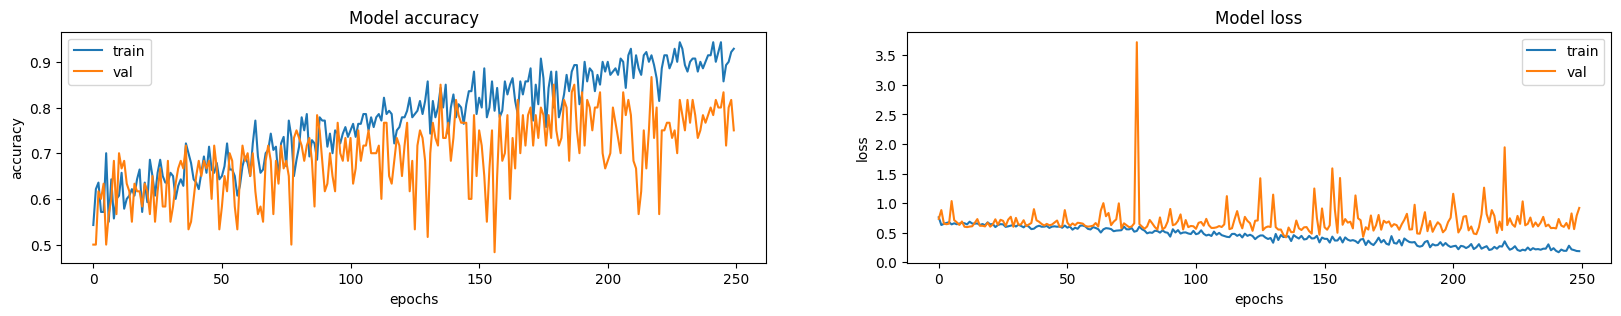

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(20, 3))
ax = ax.ravel()

for i, metric in enumerate(["accuracy", "loss"]):
    ax[i].plot(model.history.history[metric])
    ax[i].plot(model.history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()

## Make predictions on a single CT scan
Load best weights.

In [76]:
model.load_weights("3d_image_classification.keras")
prediction = model.predict(np.expand_dims(x_val[0], axis=0))[0]
scores = [1 - prediction[0], prediction[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step


In [77]:
class_names = ["normal", "abnormal"]
for score, name in zip(scores, class_names):
    print(
        "This model is %.2f percent confident that CT scan is %s"
        % ((100 * score), name)
    )

This model is 89.42 percent confident that CT scan is normal
This model is 10.58 percent confident that CT scan is abnormal
